In [63]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [64]:
%reload_ext autoreload

In [ ]:
import json

from dotenv import load_dotenv
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    ToolMessage,
)
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import add_messages
from langgraph.types import Command

from agent_setup import build_agent, call_agent
from nodes import agent_node, tool_node
from tools.registry import get_tools
from workflow import build_workflow

load_dotenv()

x:\Langraph\Projects\voice_assisted_file_opener\venv\Lib\site-packages\langchain_core\utils\pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


True

### PROMPTS

In [ ]:
from policies import safety_policy
from prompts.base_prompt import base_prompt
from prompts.apps_files_prompt import apps_files_prompt
from prompts.folder_prompt import folder_prompt 

### AGENT SETUP

In [3]:
prompt = ChatPromptTemplate.from_messages([
    ("system", 
    f"""
    1. General Instructions:
        {base_prompt}
    \n

    2. Safety Instructions:
        {safety_policy}

    3. Tool Instructions:

    a. Applications/Files Tools:
        {apps_files_prompt} 
        \n 
    b. Folder Tools:
        {folder_prompt}
        \n
    """),
    MessagesPlaceholder(variable_name="messages")
])

In [4]:
from llm import init_llm
from state import AssistantState

llm = init_llm()
tool_reg = get_tools()
tools = tool_reg['tool_objs']
agent = build_agent(llm=llm, prompt=prompt, tools=tools)
call_agent_node = agent_node(agent)

nodes = {
    "Tool": tool_node,
    "Agent": call_agent_node
}

checkpointer = MemorySaver()

workflow = build_workflow(nodes=nodes, checkpointer=checkpointer)

### Testing

In [40]:
test_state: AssistantState = ({
    "messages": [HumanMessage("List the contents of X:")]
})

# "messages" is passed to MessagePlaceholder in the prompt
response = call_agent(test_state)

test_state['messages'] = add_messages(test_state['messages'], response['messages'])

print(response)

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'function': {'arguments': '{"path": "X:\\\\"}', 'name': 'list_subdirs_tool', 'description': None}, 'id': 'chatcmpl-tool-cac4815c641649c2a68c6f7a433cafc5', 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 2815, 'total_tokens': 2839}, 'model_name': 'Qwen/Qwen3-Coder-Next', 'system_fingerprint': '', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a05371-b46e-79e1-96f6-e4f8139194c6-0', tool_calls=[{'name': 'list_subdirs_tool', 'args': {'path': 'X:\\'}, 'id': 'chatcmpl-tool-cac4815c641649c2a68c6f7a433cafc5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2815, 'output_tokens': 24, 'total_tokens': 2839})]}


##### Extract tool call

In [43]:
tool_call = response['messages'].tool_calls[-1]
print("Tool Call:", tool_call)

tool_res = tool_names[tool_call['name']].invoke(tool_call['args'])
print("Tool Result:", tool_res)

tool_message = ToolMessage(
    content=json.dumps(tool_res),
    name=tool_call['name'],
    tool_call_id = tool_call['id']
)

test_state['messages'] = add_messages(test_state['messages'], [tool_message])

AttributeError: 'list' object has no attribute 'tool_calls'

In [ ]:
print(test_state['messages'])

[HumanMessage(content='Open file explorer', additional_kwargs={}, response_metadata={}, id='1bb5ab21-52a3-4d8e-806e-3eb5732c770a'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'try_direct_open', 'arguments': '{"name": "File Explorer"}'}, '__gemini_function_call_thought_signatures__': {'a214ec18-7478-495d-bbc8-c00f79d5e5da': 'CuMDARFNMg/a63VslH1O4UIMhWgkUJgk0mLSNNvS3VsXD+wWeZ8vyOFL4VAmL/YFlHkqvECJtDLFGmcGUmvSOCFQgr69XVxd5XbAnaTFy9SAVamRe+3soCEQMUmEC2IQbGKAIakxRGJVwmjw8Wd8b/5UWUUrEQoLpsS9Jji/G8Jcm9Qu7dNBwuqvNuw9UXIruXsynzQEK9MKZmhlJ/Y0q8etK4UL2lDQQ0qMZFCQ8KuorVESkbHINkm8uexnL+OayRBQK/MCKw4dWMWX3AzdWM9firYnY4IzqhNPgq0Qx2KXSKpfbSixX0c+CpO+kzdkjuC+xWQOzH9miiEcOOux9vzKwCaj8kbsMhRYy/YpEdCovRvSBjy4V6NINOj3oQRbgyLnJh0iNSP4QE/VMavYy7GeVAzNY8NN98Syuc2dF3o5Obi2248BiBUkj8qRe5S9lVwWp3kvVrapf0AlqtRuOL69WW5urzIAMb1Rzblv5r32HaopewNAsekmSUNB0Y5uLZrbgmO5AFsJfQRFRyE/Fxu3rPg6/T6TsCaWz6/R3sU/oe5f8r1sL6Yb26Q+FBkpxQDZJboQwIXniR9Te0sYE9XdWn9WW4TmwAdoiJAc/h9bERMJ/dQuxl1+Cd5cnszaI2sXhb8m'}

### CREATE WORKFLOW

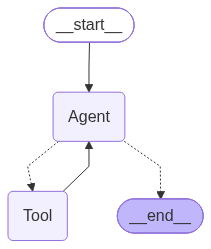

In [25]:
from IPython.display import Image
Image(voice_agent.get_graph().draw_mermaid_png())

In [5]:
# audio_file = record_audio()

# text = speech_to_text(audio_file)
# print("Prompt:", text)

config = {
    "configurable": {
        "thread_id": 123
    }
}

def action(text: str):
    test_state: AssistantState = ({
    "messages": [HumanMessage(text)]
    })

    result = workflow.invoke(test_state, config=config)
    if "__interrupt__" in result:
        user_in = input("YES / NO?: ")
        result = workflow.invoke(
            Command(resume=user_in),
            config=config
        )

    return result

In [11]:
print("Hello!... How can I help you:\n")
while True:
    user_in = input("")

    if user_in in ["exit", "quit", "e", "q"]:
        print("Exited successfully")
        break

    result = action(user_in)
    print(result["messages"][-1].content)
    print("\n\n")
    print(result)

# print(action(user_in))
# print(result)

Hello!... How can I help you:



Permission denied while listing X:\$RECYCLE.BIN\S-1-5-21-2800687128-566568502-1112790091-1000
Permission denied while listing X:\System Volume Information


I found a folder named "test" at the root of the X: drive (X:\test). Since deleting a folder is a destructive operation that removes all its contents, I need your confirmation before proceeding.

Do you want me to delete **X:\test**? Please confirm.



{'messages': [HumanMessage(content='open notepad', additional_kwargs={}, response_metadata={}, id='b5b0e761-46ea-492e-b39f-ec280e039381'), HumanMessage(content='open notepad', additional_kwargs={}, response_metadata={}, id='10d7d8da-8fcb-41b9-b1e9-e710fe4b7731'), AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user wants to open Notepad. Let me check the available tools. The first step is to try opening the application directly. The tool \'try_direct_open\' is for that. The argument needed is the name, which in this case is "notepad". I should call that function. If that fails, maybe try the shortcut or index search, but since Notepad is a common app, direct open should work. Let me make sure the name is correct.

KeyboardInterrupt: 

In [10]:
for message in result["messages"]:
    if isinstance(message, AIMessage):
        print(message)
        break

content='' additional_kwargs={'reasoning_content': 'Okay, the user wants to open Notepad. Let me check the available tools. The first step is to try opening the application directly. The tool \'try_direct_open\' is for that. The argument needed is the name, which in this case is "notepad". I should call that function. If that fails, maybe try the shortcut or index search, but since Notepad is a common app, direct open should work. Let me make sure the name is correct. The user said "open notepad", so the name parameter is "notepad". I\'ll use try_direct_open with name "notepad".\n', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'Okay, the user wants to open Notepad. Let me check the available tools. The first step is to try opening the application directly. The tool \'try_direct_open\' is for that. The argument needed is the name, which in this case is "notepad". I should call that function. If that fails, maybe try the shortcut or index sear

In [15]:
test_state: AssistantState = ({
    "messages": [HumanMessage("Remove folder test from X:")]
    })

workflow.invoke(test_state, config=config)


Tool calling process failed
Traceback (most recent call last):
  File "x:\Langraph\Projects\voice_assisted_file_opener\agent\nodes.py", line 30, in tool_node
    approval = interrupt(
        {
    ...<3 lines>...
        }
    )
  File "x:\Langraph\Projects\voice_assisted_file_opener\venv\Lib\site-packages\langgraph\types.py", line 967, in interrupt
    raise GraphInterrupt(
    ...<6 lines>...
    )
langgraph.errors.GraphInterrupt: (Interrupt(value={'action': 'remove_dir', 'args': {'path': 'X:\\test'}, 'message': 'This action will have irreversible consequences'}, id='db4ee22e97b2bfb4409eb5e567ee6363'),)


{'messages': [HumanMessage(content='open notepad', additional_kwargs={}, response_metadata={}, id='b5b0e761-46ea-492e-b39f-ec280e039381'),
  HumanMessage(content='open notepad', additional_kwargs={}, response_metadata={}, id='10d7d8da-8fcb-41b9-b1e9-e710fe4b7731'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user wants to open Notepad. Let me check the available tools. The first step is to try opening the application directly. The tool \'try_direct_open\' is for that. The argument needed is the name, which in this case is "notepad". I should call that function. If that fails, maybe try the shortcut or index search, but since Notepad is a common app, direct open should work. Let me make sure the name is correct. The user said "open notepad", so the name parameter is "notepad". I\'ll use try_direct_open with name "notepad".\n', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'Okay, the user wants to open Notepad. Le

In [ ]:
user_input = input("Y / N?: ")
workflow.invoke(
    Command(resume=user_input),
    config=config)

Tool Call: {'name': 'remove_dir', 'args': {'path': 'X:\\abc'}, 'id': 'chatcmpl-tool-14a6203111e841f5bd777aadae1723a1', 'type': 'tool_call'}


{'messages': [HumanMessage(content='close abc', additional_kwargs={}, response_metadata={}, id='671f5969-abed-416f-9e29-d46edb3bbba3'),
  AIMessage(content='I\'ll close the application named "abc" for you.', additional_kwargs={'reasoning_content': 'The user wants to close an application named "abc". I need to use the close_app tool to close this application. Let me first check what applications are running to see if "abc" is actually running, and then close it.\n\nActually, I should just try to close it directly since the user is asking to close it. Let me use the close_app tool with the name "abc".', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'The user wants to close an application named "abc". I need to use the close_app tool to close this application. Let me first check what applications are running to see if "abc" is actually running, and then close it.\n\nActually, I should just try to close it directly since the user is asking to clo

In [23]:
def show_reasoning(state: AssistantState):
    for message in state["messages"]:
        if isinstance(message, AIMessage):

            reasoning = message.additional_kwargs.get(
                "reasoning_content"
            )

            if reasoning:
                print(f"\nReasoning:\n{reasoning}")

            for tool_call in message.tool_calls:
                print(
                    f"Decision → {tool_call['name']}"
                    f"({tool_call['args']})"
                )

        elif isinstance(message, ToolMessage):
            print(
                f"Result ← {message.name}: {message.content}"
            )

In [24]:
show_reasoning(AssistantState)